In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

#1 загрузка изображения

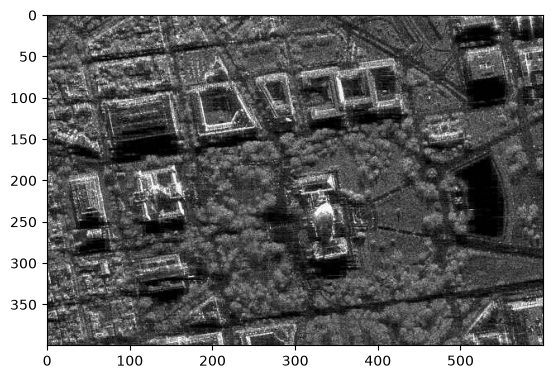

In [29]:
image = cv2.imread('sar_1_gray.jpg')
plt.imshow(image)

#2 построение гистограммы

In [ ]:
histSize = 256
histRange = (0, 256)
accumulate = False

img_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

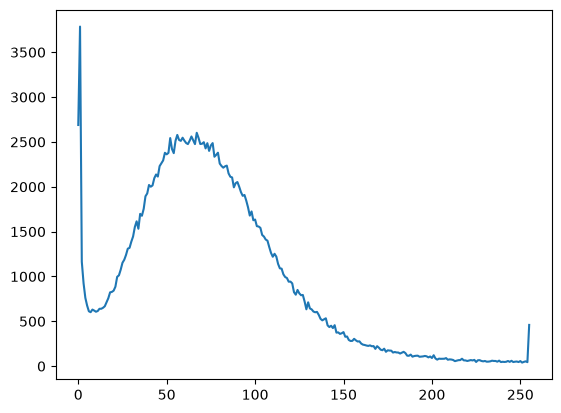

In [10]:
plt.plot(img_hist)

#3 гамма коррекция

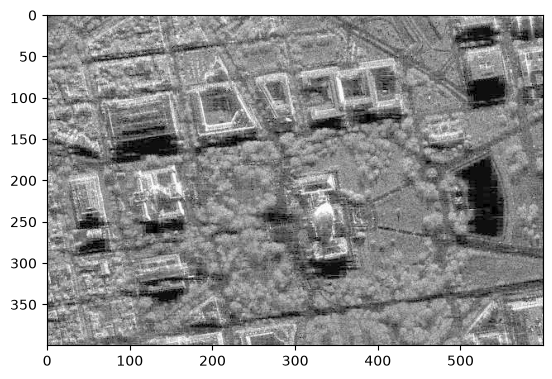

In [32]:
gamma_corr_less = (np.power(image/255, 0.5) * 255).astype("uint8")
plt.imshow(gamma_corr_less) 

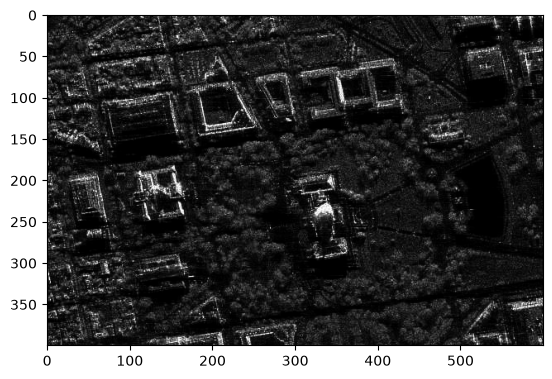

In [22]:
gamma_corr_more = (np.power(image/255, 2) * 255).astype("uint8")
plt.imshow(gamma_corr_more) 

#4 сравнение

In [19]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image, gamma_corr_less, full=True, channel_axis=-1)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 0.7875008686792752


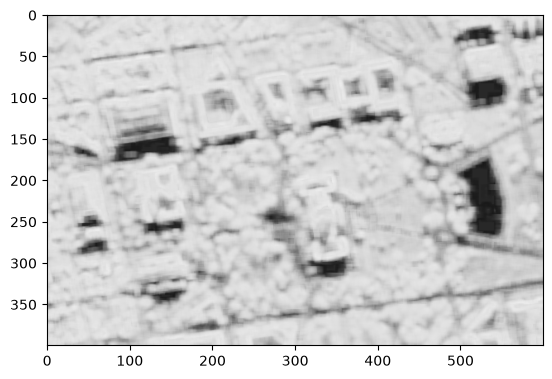

In [20]:
plt.imshow(diff)

In [23]:
mse = mean_squared_error(image, gamma_corr_less)
mse

np.float64(3250.429145833333)

In [33]:
(ssim, diff) = structural_similarity(image, gamma_corr_more, full=True, channel_axis=-1)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 0.5270459922820343


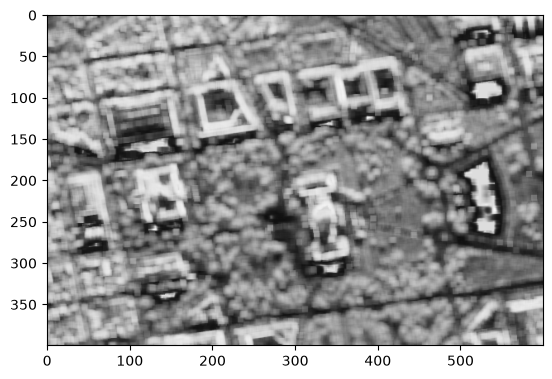

In [34]:
plt.imshow(diff)

In [26]:
mse = mean_squared_error(image, gamma_corr_more)
mse

np.float64(2383.7636375)

#5 статическая цветокоррекция

In [36]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

eq_gray = cv2.equalizeHist(image_gray)

In [37]:
s_mean = eq_gray.mean()
s_std = eq_gray.std()

t_mean = image_gray.mean()
t_std = image_gray.std()

stat_corr = s_mean + (image_gray - t_mean) * (s_std/t_std)

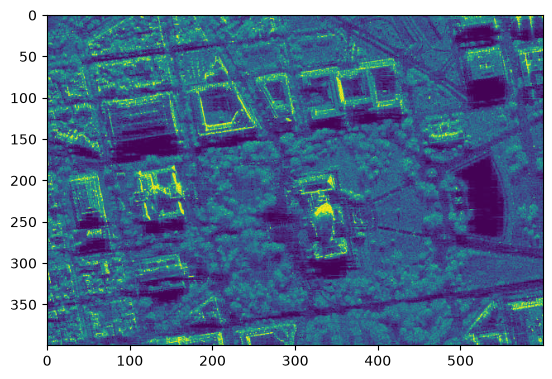

In [38]:
plt.imshow(stat_corr)

#6 алгоритмы пороговой фильтрации

In [43]:
_,thresh1 = cv2.threshold(image_gray,150,255,cv2.THRESH_BINARY)

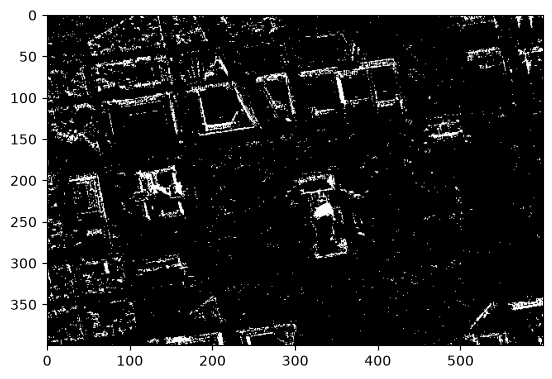

In [44]:
plt.imshow(thresh1, cmap='gray')

In [49]:
_,thresh1 = cv2.threshold(image_gray,100,150,cv2.THRESH_BINARY)

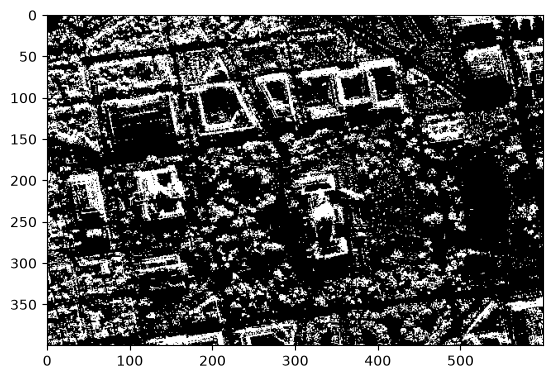

In [50]:
plt.imshow(thresh1, cmap='gray')

In [59]:
_,thresh1 = cv2.threshold(image_gray,123,156,cv2.THRESH_TOZERO)

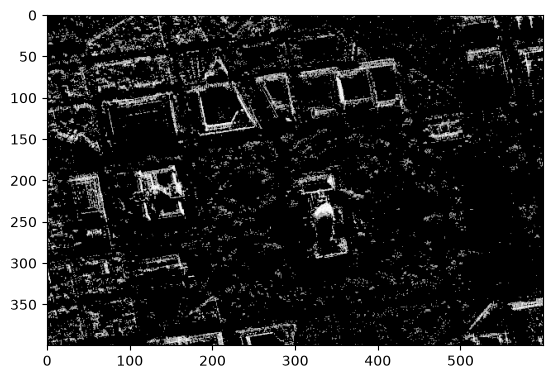

In [60]:
plt.imshow(thresh1, cmap='gray')

In [61]:
_,thresh1 = cv2.threshold(image_gray,123,156,cv2.THRESH_OTSU)

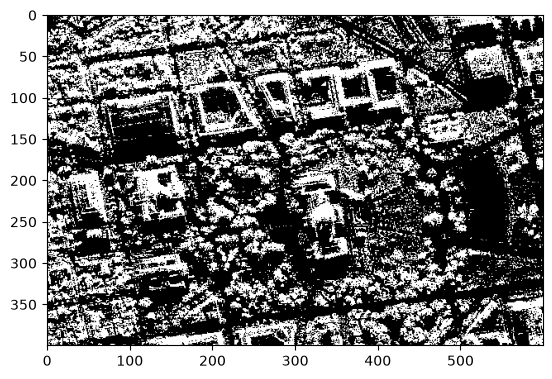

In [62]:
plt.imshow(thresh1, cmap='gray')

In [65]:
_,thresh1 = cv2.threshold(image_gray,103,246,cv2.THRESH_MASK)

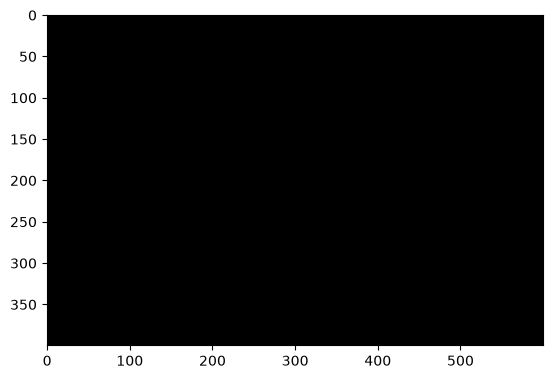

In [66]:
plt.imshow(thresh1, cmap='gray')

In [71]:
_,thresh1 = cv2.threshold(image_gray,203,246,cv2.THRESH_TRIANGLE)

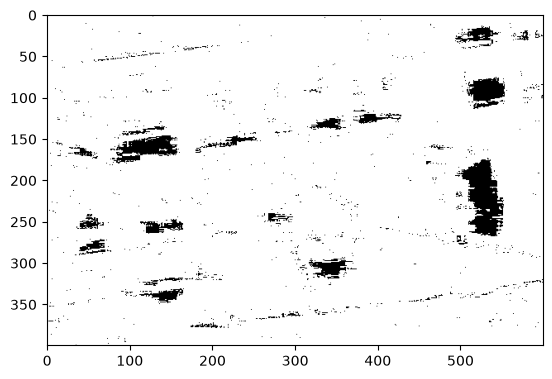

In [72]:
plt.imshow(thresh1, cmap='gray')

In [77]:
_,thresh1 = cv2.threshold(image_gray,103,146,cv2.THRESH_TRUNC)

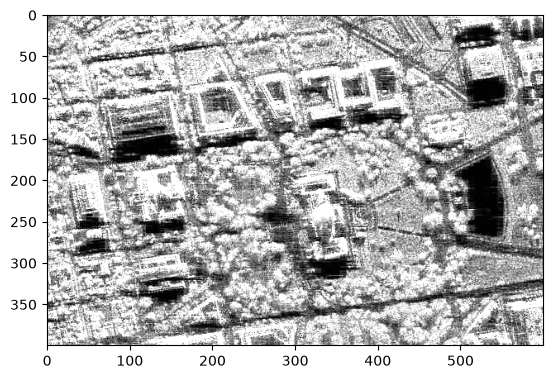

In [78]:
plt.imshow(thresh1, cmap='gray')